# Dual ping latency → DataFrame

Источник: `output/ping_dual_2h.log` (VPS: `/var/log/spread/ping_dual_2h.log`).

`latency_ms` = локальное время − exchange timestamp (возраст котировки, **не ICMP**).

После ячейки загрузки доступен `df` (alias `df_latency`).

In [1]:
from pathlib import Path
import re
from datetime import datetime

import pandas as pd

ROOT = Path("..").resolve()
LOG = ROOT / "output" / "ping_dual_2h.log"

ts_re = re.compile(r"^(\d{4}-\d{2}-\d{2}T[^\t]+)\t(okx|bybit)\t(.*)$")
kv_re = re.compile(r"(\w+)=([^\t]+)")


def _to_float(v):
    if v in (None, "None", ""):
        return None
    try:
        return float(v)
    except ValueError:
        return None


rows = []
with LOG.open() as f:
    for line in f:
        line = line.rstrip("\n")
        m = ts_re.match(line)
        if not m:
            continue
        ts_s, exch, rest = m.groups()
        kvs = dict(kv_re.findall(rest))
        if "latency_ms" not in kvs:
            continue
        rows.append(
            {
                "timestamp": datetime.fromisoformat(ts_s.replace("Z", "+00:00")),
                "exchange": exch,
                "latency_ms": float(kvs["latency_ms"]),
                "age_ts_ms": _to_float(kvs.get("age_ts_ms")),
                "age_cts_ms": _to_float(kvs.get("age_cts_ms")),
                "remaining_sec": _to_float(kvs.get("remaining_sec")),
            }
        )

df = pd.DataFrame(rows)
df_latency = df  # alias

print("log:", LOG)
print("columns:", list(df.columns))
print("rows:", len(df))
print(df["exchange"].value_counts().to_string())
df.head()

log: /Users/mishatrubik/Desktop/spread/output/ping_dual_2h.log
columns: ['timestamp', 'exchange', 'latency_ms', 'age_ts_ms', 'age_cts_ms', 'remaining_sec']
rows: 67477
exchange
bybit    34230
okx      33247


,timestamp,exchange,latency_ms,age_ts_ms,age_cts_ms,remaining_sec
0,2026-08-05 10:33:36+00:00,bybit,509.0,509.0,510.0,7199.8
1,2026-08-05 10:33:36.337000+00:00,okx,31.0,31.0,NaN,7199.5
2,2026-08-05 10:33:36.369000+00:00,bybit,18.0,18.0,21.0,7199.5
3,2026-08-05 10:33:36.435000+00:00,okx,29.0,29.0,NaN,7199.4
4,2026-08-05 10:33:36.636000+00:00,okx,30.0,30.0,NaN,7199.2


In [2]:
df.describe(include="all")

,timestamp,exchange,latency_ms,age_ts_ms,age_cts_ms,remaining_sec
count,67477,67477,67477.000000,67477.000000,34230.000000,67477.000000
unique,NaN,2,NaN,NaN,NaN,NaN
top,NaN,bybit,NaN,NaN,NaN,NaN
freq,NaN,34230,NaN,NaN,NaN,NaN
mean,2026-08-05 11:11:13.832642304+00:00,NaN,24.876032,24.876032,23.562635,4941.999913
min,2026-08-05 10:33:36+00:00,NaN,17.000000,17.000000,18.000000,2564.200000
25%,2026-08-05 10:52:29.436000+00:00,NaN,21.000000,21.000000,22.000000,3826.700000
50%,2026-08-05 11:10:40.092000+00:00,NaN,23.000000,23.000000,23.000000,4975.700000
75%,2026-08-05 11:29:49.150000128+00:00,NaN,30.000000,30.000000,25.000000,6066.400000
max,2026-08-05 11:50:51.632000+00:00,NaN,509.000000,509.000000,510.000000,7199.800000


In [3]:
df.groupby("exchange")["latency_ms"].describe()

,count,mean,std,min,25%,50%,75%,max
exchange,,,,,,,,
bybit,34230.0,20.256559,5.203125,17.0,19.0,21.0,21.0,509.0
okx,33247.0,29.632087,0.804803,28.0,29.0,30.0,30.0,48.0


## Опционально: простой график

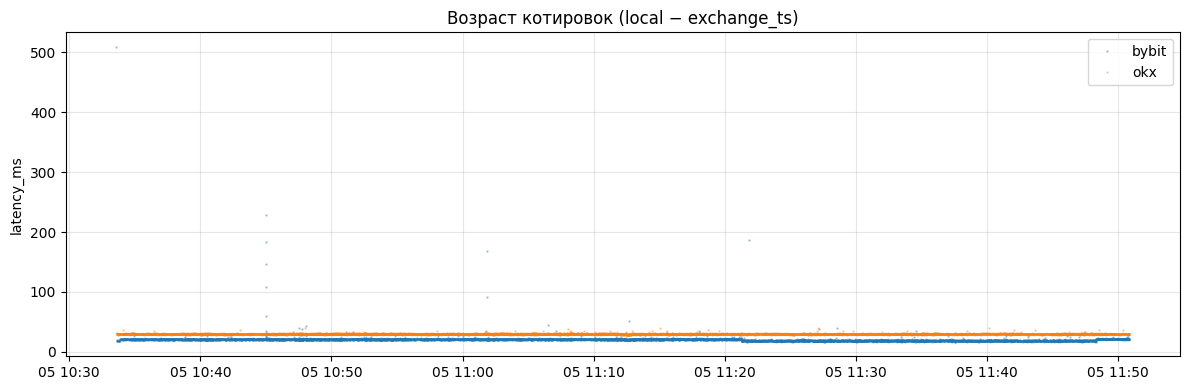

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
for exch, g in df.groupby("exchange"):
    step = max(1, len(g) // 8000)
    g = g.iloc[::step]
    ax.plot(g["timestamp"], g["latency_ms"], ".", ms=1.5, alpha=0.35, label=exch)
ax.set_ylabel("latency_ms")
ax.set_title("Возраст котировок (local − exchange_ts)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()